In [6]:
# 라이브러리 및 설정 / 키포인트 추출용 함수 / 파인튜닝 영상 키포인트 추출

import cv2
import mediapipe as mp
import numpy as np
import pickle
import os
from collections import defaultdict
from tensorflow.keras.models import load_model
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.utils import to_categorical
from ultralytics import YOLO

SEQUENCE_LEN = 15
video_dir    = './video_finetune'

yolo    = YOLO('yolo11n.pt')
mp_pose = mp.solutions.pose

def extract_keypoints_crop(frame, pose):
    H, W = frame.shape[:2]
    results = yolo(frame, classes=0, conf=0.5, verbose=False)

    main_box = None
    max_area = 0
    for box in results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        area = (x2-x1)*(y2-y1)
        if area > max_area:
            max_area = area
            main_box = (x1, y1, x2, y2)
    if main_box is None:
        return None

    x1, y1, x2, y2 = main_box
    pad = 20
    cx1, cy1 = max(0, x1-pad), max(0, y1-pad)
    cx2, cy2 = min(W, x2+pad), min(H, y2+pad)
    crop = frame[cy1:cy2, cx1:cx2]
    if crop.size == 0:
        return None

    result = pose.process(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    if not result.pose_landmarks:
        return None

    kp = []
    for lm in result.pose_landmarks.landmark:
        abs_x = lm.x * (cx2 - cx1) + cx1
        abs_y = lm.y * (cy2 - cy1) + cy1
        kp.extend([abs_x / W, abs_y / H, lm.z, lm.visibility])
    return np.array(kp, dtype=np.float32)

# 새 영상 label_map
new_label_map = {}
for i in range(1, 13):
    new_label_map[f'f_run_{i:02d}']   = 'run'
for i in range(1, 9):
    new_label_map[f'f_stand_{i:02d}'] = 'stand'
for i in range(1, 11):
    new_label_map[f'f_walk_{i:02d}']  = 'walk'

new_data      = []
new_labels    = []
new_video_ids = []

# 기존 video_id 이후로 부여
old_video_ids = np.load('./pose_fps/aug_video_ids.npy')
vid_offset    = int(old_video_ids.max()) + 1

with mp_pose.Pose(
    model_complexity=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
) as pose:
    for vid_idx, (filename, label) in enumerate(new_label_map.items()):
        video_path = os.path.join(video_dir, filename + '.mp4')
        if not os.path.exists(video_path):
            print(f"⚠️  파일 없음: {filename}")
            continue
        cap = cv2.VideoCapture(video_path)
        frame_count = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            kp = extract_keypoints_crop(frame, pose)
            if kp is not None:
                new_data.append(kp)
                new_labels.append(label)
                new_video_ids.append(vid_idx + vid_offset)
                frame_count += 1
        cap.release()
        print(f"✅ {filename} ({label}): {frame_count}프레임")

new_data      = np.array(new_data)
new_labels    = np.array(new_labels)
new_video_ids = np.array(new_video_ids)

print(f"\n=== 새 영상 클래스별 프레임 수 ===")
for lbl in np.unique(new_labels):
    print(f"  {lbl}: {np.sum(new_labels == lbl)}")

✅ f_run_01 (run): 258프레임
✅ f_run_02 (run): 128프레임
✅ f_run_03 (run): 200프레임
✅ f_run_04 (run): 116프레임
✅ f_run_05 (run): 524프레임
✅ f_run_06 (run): 301프레임
✅ f_run_07 (run): 240프레임
✅ f_run_08 (run): 833프레임
✅ f_run_09 (run): 1130프레임
✅ f_run_10 (run): 160프레임
✅ f_run_11 (run): 856프레임
✅ f_run_12 (run): 96프레임
✅ f_stand_01 (stand): 345프레임
✅ f_stand_02 (stand): 444프레임
✅ f_stand_03 (stand): 335프레임
✅ f_stand_04 (stand): 149프레임
✅ f_stand_05 (stand): 200프레임
✅ f_stand_06 (stand): 662프레임
✅ f_stand_07 (stand): 282프레임
✅ f_stand_08 (stand): 515프레임
✅ f_walk_01 (walk): 165프레임
✅ f_walk_02 (walk): 178프레임
✅ f_walk_03 (walk): 196프레임
✅ f_walk_04 (walk): 75프레임
✅ f_walk_05 (walk): 348프레임
✅ f_walk_06 (walk): 660프레임
✅ f_walk_07 (walk): 600프레임
✅ f_walk_08 (walk): 433프레임
✅ f_walk_09 (walk): 93프레임
✅ f_walk_10 (walk): 648프레임

=== 새 영상 클래스별 프레임 수 ===
  run: 4842
  stand: 2932
  walk: 3396


In [7]:
# 기존 데이터와 병합

old_data      = np.load('./pose_fps/aug_data.npy')
old_labels    = np.load('./pose_fps/aug_labels.npy')
old_video_ids = np.load('./pose_fps/aug_video_ids.npy')

merged_data      = np.concatenate([old_data,      new_data])
merged_labels    = np.concatenate([old_labels,    new_labels])
merged_video_ids = np.concatenate([old_video_ids, new_video_ids])

print(f"=== 병합 후 클래스별 프레임 수 ===")
for lbl in np.unique(merged_labels):
    print(f"  {lbl}: {np.sum(merged_labels == lbl)}")
print(f"총 {len(merged_data)}프레임")

=== 병합 후 클래스별 프레임 수 ===
  run: 11762
  stand: 9447
  walk: 12206
총 33415프레임


In [10]:
# 시퀀스 생성 및 split

def make_sequences(frames, labels, video_ids, seq_len):
    X_seq, y_seq, groups = [], [], []
    for vid in np.unique(video_ids):
        mask = np.where(video_ids == vid)[0]
        vf = frames[mask]
        vl = labels[mask]
        n  = len(vf)
        if n < seq_len:
            continue
        indices   = np.arange(seq_len)[None, :] + np.arange(n - seq_len + 1)[:, None]
        windows_f = vf[indices]
        windows_l = vl[indices]
        first_label = windows_l[:, 0]
        all_same    = np.all(windows_l == first_label[:, None], axis=1)
        valid       = np.where(all_same)[0]
        if len(valid) == 0:
            continue
        X_seq.append(windows_f[valid])
        y_seq.extend(windows_l[valid, -1].tolist())
        groups.extend([vid] * len(valid))
    X_seq = np.concatenate(X_seq, axis=0)
    return X_seq, np.array(y_seq), np.array(groups)

# fit_transform 아닌 transform 사용 (라벨 순서 유지)
le = pickle.load(open('./model/label_encoder.pkl', 'rb'))
y_enc       = le.transform(merged_labels)
num_classes = len(le.classes_)

X_seq, y_seq, groups = make_sequences(merged_data, y_enc, merged_video_ids, SEQUENCE_LEN)
print(f"시퀀스 수: {len(X_seq)}, shape: {X_seq.shape}")

train_idx_list, val_idx_list = [], []
class_to_vids = defaultdict(set)
for i, (g, y) in enumerate(zip(groups, y_seq)):
    class_to_vids[y].add(g)

np.random.seed(21)
for cls, vids in class_to_vids.items():
    vids = np.array(sorted(vids))
    np.random.shuffle(vids)
    n_val      = max(1, int(len(vids) * 0.2))
    val_vids   = set(vids[:n_val])
    train_vids = set(vids[n_val:])
    for i, g in enumerate(groups):
        if y_seq[i] != cls: continue
        (val_idx_list if g in val_vids else train_idx_list).append(i)

X_train = X_seq[train_idx_list]; y_train = y_seq[train_idx_list]
X_val   = X_seq[val_idx_list];   y_val   = y_seq[val_idx_list]

print(f"학습: {len(X_train)} / 검증: {len(X_val)}")

print("\n=== 클래스 분포 확인 ===")
for cls in sorted(np.unique(y_seq)):
    name = le.inverse_transform([cls])[0]
    tr   = np.sum(y_train == cls)
    va   = np.sum(y_val   == cls)
    print(f"  {name}: 학습 {tr} / 검증 {va}")

print("\n=== 학습셋 vs 검증셋 키포인트 평균 비교 ===")
all_ok = True
for cls in sorted(np.unique(y_seq)):
    name    = le.inverse_transform([cls])[0]
    tr_mean = X_train[y_train == cls].mean()
    va_mean = X_val[y_val   == cls].mean()
    diff    = abs(tr_mean - va_mean)
    flag    = "⚠️ 차이 큼" if diff > 0.05 else "✅"
    if diff > 0.05: all_ok = False
    print(f"  {name}: 학습 {tr_mean:.4f} / 검증 {va_mean:.4f} / 차이 {diff:.4f} {flag}")
if not all_ok:
    print("⚠️ 차이 큰 클래스 있음 → seed 변경 필요")
else:
    print("✅ 모든 클래스 정상")

y_train_oh = to_categorical(y_train, num_classes)
y_val_oh   = to_categorical(y_val,   num_classes)

시퀀스 수: 32365, shape: (32365, 15, 132)
학습: 25098 / 검증: 7267

=== 클래스 분포 확인 ===
  run: 학습 8843 / 검증 2541
  stand: 학습 7058 / 검증 2067
  walk: 학습 9197 / 검증 2659

=== 학습셋 vs 검증셋 키포인트 평균 비교 ===
  run: 학습 0.4459 / 검증 0.4374 / 차이 0.0085 ✅
  stand: 학습 0.4488 / 검증 0.4524 / 차이 0.0036 ✅
  walk: 학습 0.4699 / 검증 0.4655 / 차이 0.0044 ✅
✅ 모든 클래스 정상


In [11]:
# 파인튜닝

model = load_model('./model/action_model_v3.h5')

# LSTM 동결, Dense만 재학습
for layer in model.layers:
    if 'lstm' in layer.name:
        layer.trainable = False
    else:
        layer.trainable = True

model.compile(
    optimizer=Adam(0.0003),
    loss=CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=50,
    batch_size=32,
    callbacks=[
        EarlyStopping(patience=15, restore_best_weights=True, monitor='val_accuracy'),
        ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-5, verbose=1)
    ]
)

model.save('./model/action_model_v5.h5')
print("✅ 파인튜닝 완료: action_model_v5.h5")

Epoch 1/50
785/785 [==============================] - 6s 5ms/step - loss: 0.5849 - accuracy: 0.8417 - val_loss: 0.6649 - val_accuracy: 0.7771 - lr: 3.0000e-04
Epoch 2/50
785/785 [==============================] - 3s 4ms/step - loss: 0.5752 - accuracy: 0.8428 - val_loss: 0.6728 - val_accuracy: 0.7764 - lr: 3.0000e-04
Epoch 3/50
785/785 [==============================] - 3s 4ms/step - loss: 0.5713 - accuracy: 0.8428 - val_loss: 0.6710 - val_accuracy: 0.7761 - lr: 3.0000e-04
Epoch 4/50
785/785 [==============================] - 3s 4ms/step - loss: 0.5714 - accuracy: 0.8443 - val_loss: 0.6865 - val_accuracy: 0.7747 - lr: 3.0000e-04
Epoch 5/50
785/785 [==============================] - 3s 4ms/step - loss: 0.5733 - accuracy: 0.8435 - val_loss: 0.6760 - val_accuracy: 0.7760 - lr: 3.0000e-04
Epoch 6/50
779/785 [============================>.] - ETA: 0s - loss: 0.5717 - accuracy: 0.8459
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
785/785 [========================

C:\Users\user\miniconda3\envs\dk_project\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


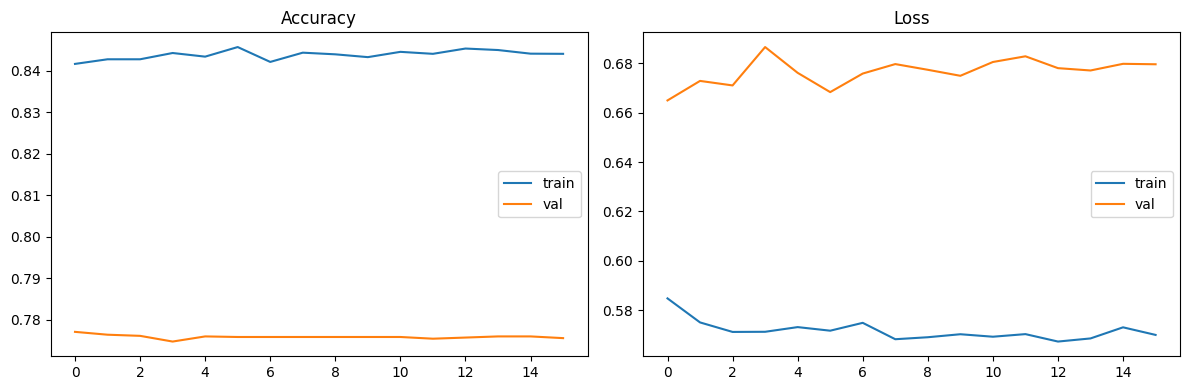

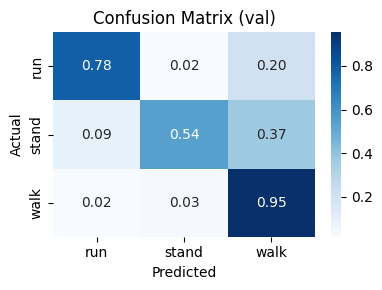

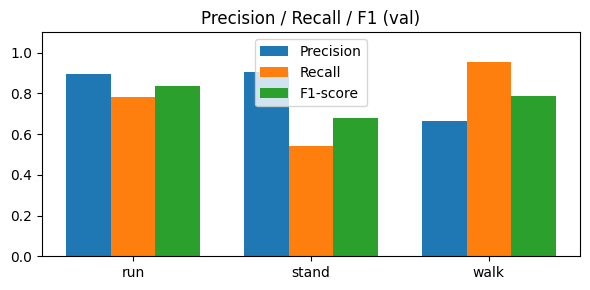

In [12]:
# 파인튜닝 결과 시각화

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.legend()
plt.tight_layout(); plt.show()

y_pred     = model.predict(X_val, verbose=0)
y_pred_cls = np.argmax(y_pred, axis=1)

cm      = confusion_matrix(y_val, y_pred_cls)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(4, 3))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix (val)')
plt.tight_layout(); plt.show()

report = classification_report(y_val, y_pred_cls,
                                target_names=le.classes_, output_dict=True)
classes   = le.classes_
precision = [report[c]['precision'] for c in classes]
recall    = [report[c]['recall']    for c in classes]
f1        = [report[c]['f1-score']  for c in classes]

x = np.arange(len(classes))
w = 0.25
plt.figure(figsize=(6, 3))
plt.bar(x - w, precision, w, label='Precision')
plt.bar(x,     recall,    w, label='Recall')
plt.bar(x + w, f1,        w, label='F1-score')
plt.xticks(x, classes)
plt.ylim(0, 1.1)
plt.title('Precision / Recall / F1 (val)')
plt.legend(); plt.tight_layout(); plt.show()